# 1. Setup
Bài thực hành sử dụng bộ data Titanic để dự đoán tỉ lệ sống sót của người trên tàu.

Authentication Kaggle:

In [1]:
# === Kaggle Auth via Google Drive ===
# One-time: upload kaggle.json to your Google Drive root, then paste this cell
import os, json

if not os.path.exists(os.path.expanduser('~/.kaggle/kaggle.json')):
    from google.colab import drive
    drive.mount('/content/drive')
    os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
    !cp /content/drive/MyDrive/kaggle.json ~/.kaggle/kaggle.json

# Both legacy kaggle package and new kaggle SDK need the token
with open(os.path.expanduser('~/.kaggle/kaggle.json')) as f:
    creds = json.load(f)
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_' + creds['key']
print('Kaggle auth ready.')

Mounted at /content/drive
Kaggle auth ready.


Download data:

In [2]:
from pathlib import Path

iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')
if iskaggle: path = Path('../input/titanic')
else:
    path = Path('titanic')
    if not path.exists():
        import zipfile,kaggle
        kaggle.api.competition_download_cli(str(path))
        zipfile.ZipFile(f'{path}.zip').extractall(path)

100%|██████████| 34.1k/34.1k [00:00<00:00, 45.0MB/s]

Import thư viện và config:

In [3]:
from fastai.imports import *
np.set_printoptions(linewidth=130)

# 2. Data processing    

Tạo DataFrame:

In [4]:
import os
iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')

if iskaggle: path = Path('../input/titanic')
else:
    import zipfile,kaggle
    path = Path('titanic')
    kaggle.api.competition_download_cli(str(path))
    zipfile.ZipFile(f'{path}.zip').extractall(path)

df = pd.read_csv(path/'train.csv')
tst_df = pd.read_csv(path/'test.csv')
modes = df.mode().iloc[0]

titanic.zip: Skipping, found more recently modified local copy (use --force to force download)


Ta sẽ thực hiện xử lí tương tự linear model và neural network trong các phần trước.

In [5]:
def proc_data(df):
    # điền các giá trị thiếu
    df['Fare'] = df.Fare.fillna(0)
    df.fillna(modes, inplace=True)
    
    # log transform cho cột Fare
    df['LogFare'] = np.log1p(df['Fare'])
    
    # chuyển đổi các cột phân loại sang kiểu Categorical
    df['Embarked'] = pd.Categorical(df.Embarked)
    df['Sex'] = pd.Categorical(df.Sex)

proc_data(df)
proc_data(tst_df)

Điểm khác biệt là khi xử lí categorical cho các cột embarked và sex, thay vì dùng dummy hot để tạo thành nhiều cột giá trị số cho chúng, thì đối với random forest, ta chỉ cần dùng pandas để lấy ra các giá trị unique của các cột đó và gắn giá trị theo index.

In [6]:
cats=["Sex","Embarked"] # các biến categorical
conts=['Age', 'SibSp', 'Parch', 'LogFare',"Pclass"] # các biến continuous
target_col="Survived" # biến mục tiêu

1 điểm khác nữa là Pclass ở đây lại chọn làm continuous var thay vì cats var bởi vì random forest sẽ quan tâm đến tính thứ tự (hạng 1, hạng 2, hạng 3,...), chi tiết sẽ trong các phần sau.

In [7]:
df.Embarked.head() # Lấy 5 giá trị đầu tiên của cột Embarked

,Embarked
0,S
1,C
2,S
3,S
4,S


In [8]:
df.Embarked.cat.codes.head() # Lấy 5 giá trị đầu tiên của cột Embarked dưới dạng mã số (code) của các category

,0
0,2
1,0
2,2
3,2
4,2


# 3. Binary splits



Trước khi hiểu "rừng" (forest), ta phải hiểu từng "cái cây" (tree) trước, và mỗi cây thì lại có nhiều lá. Mỗi lá sẽ là 1 lần chia - split.

Trong bài toán Titanic, để dự đoán 1 người sống (1) hay chết (0), ta có thể dựa trên các cột như giới tính và tuổi.

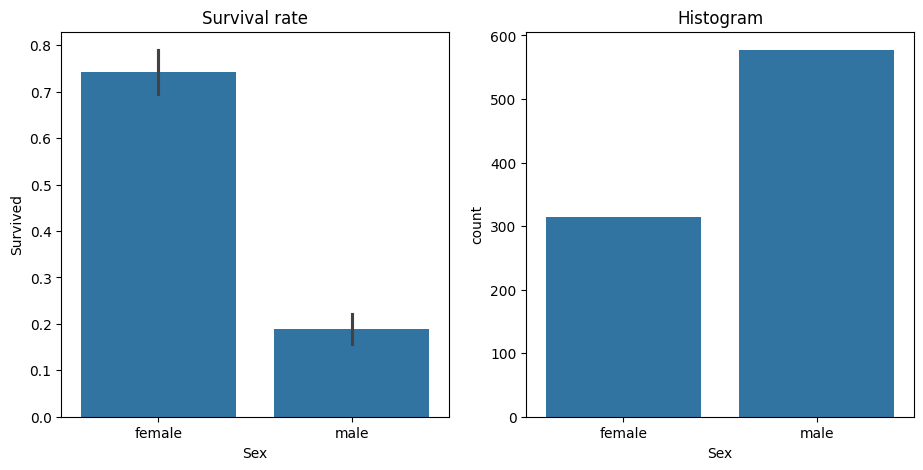

In [9]:
import seaborn as sns

# Vẽ biểu đồ cột (barplot) và biểu đồ đếm (countplot) cho cột "Sex"
fig,axs = plt.subplots(1,2, figsize=(11,5))
# Vẽ biểu đồ cột (barplot) cho tỷ lệ sống sót theo giới tính
sns.barplot(data=df, y=target_col, x="Sex", ax=axs[0]).set(title="Survival rate")
 # Vẽ biểu đồ đếm (countplot) cho số lượng nam và nữ
sns.countplot(data=df, x="Sex", ax=axs[1]).set(title="Histogram");

Qua biểu đồ, có thể thấy nhóm nữ có tỉ lệ sống sót cao hơn rất nhiều.

Ý tưởng cốt lõi của một decision tree là đặt một câu hỏi đúng hay sai. Ở dạng đơn giản nhất - Thuật toán OneR (One rule), chỉ làm một việc duy nhất: Chọn một cột và một ngưỡng và hỏi giá trị có thỏa mãn điều kiện hay không -> chia dữ liệu thành 2 nhóm nhỏ dựa trên ngưỡng.

Lý do là bởi ta đang cố nhóm những hàng giống nhau về kết quả (target) lại với nhau, ví dụ nữ = sống, nam = chết. Tuy nhiên thì khó có thể tạo ra nhóm mà chắc chắn sống hay chết như vậy nên cần dựa trên 1 thông số là độ lệch chuẩn - standard devitation, các giá trị có bị lệch quá nhiều hay không -> Có thể gọi là độ "thuần" của nhóm, và chúng ta sẽ muốn độ thuần này càng thấp cầng tốt.

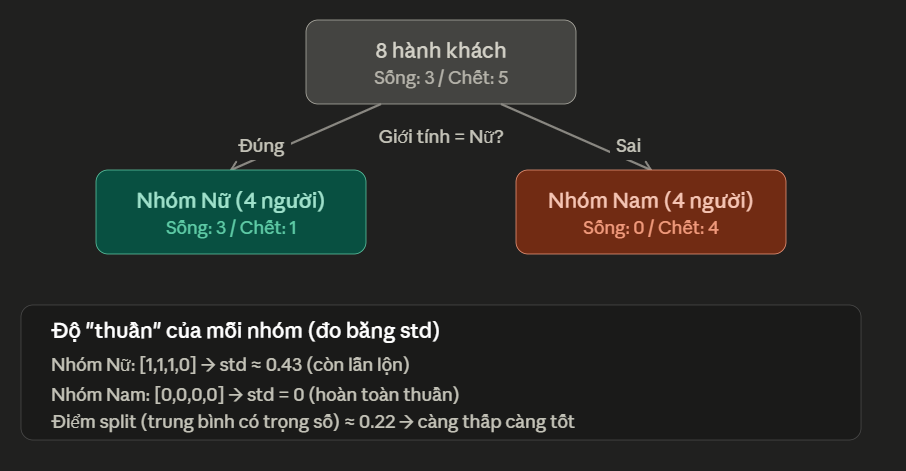

Trước tiên ta sẽ thử xây dựng lại thuật toán OneR, hay chính là 1 split với cột Sex:

In [10]:
from numpy import random
from sklearn.model_selection import train_test_split

random.seed(42)
train_df,valid_df = train_test_split(df, test_size=0.25) # chia data thành 2 tập train và validation

# data processing 
train_df[cats] = train_df[cats].apply(lambda x: x.cat.codes)
valid_df[cats] = valid_df[cats].apply(lambda x: x.cat.codes)

In [11]:
def get_features_target(df): # tách dữ liệu thành input và target
    features = df[cats+conts].copy()
    return features,df[target_col] if target_col in df else None

train_features,train_target = get_features_target(train_df)
valid_features,valid_target = get_features_target(valid_df)

Thực hiện dự đoán bằng cách hỏi: Có phải nữ không? Đây chính là ngưỡng

In [12]:
preds = valid_features.Sex==0

In [13]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(valid_target, preds) # tính độ chính xác mô hình bằng MAE, MAE càng thấp thì mô hình càng chính xác

0.21524663677130046

Ta cũng có thể thử  dự đoán trên một cột có tính thứ tự như LogFare. Trước hết quan sát dữ liệu:

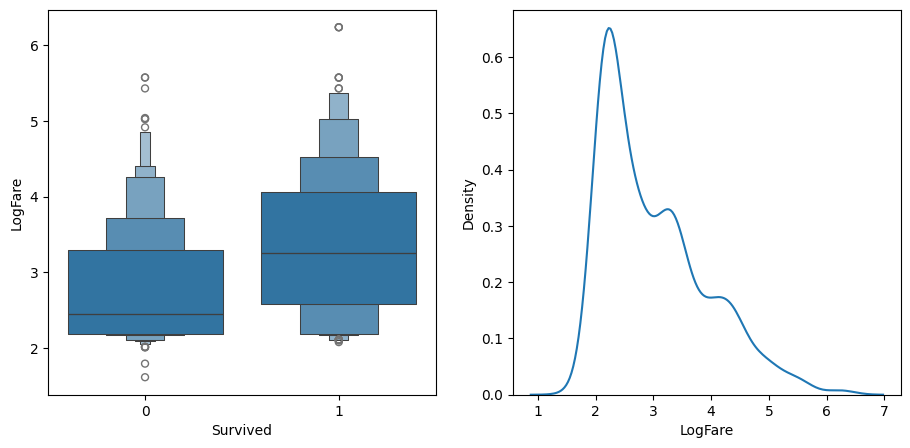

In [14]:
df_fare = train_df[train_df.LogFare>0]
fig,axs = plt.subplots(1,2, figsize=(11,5))
sns.boxenplot(data=df_fare, x=target_col, y="LogFare", ax=axs[0])
sns.kdeplot(data=df_fare, x="LogFare", ax=axs[1]);

Có thể thấy rằng những người có tỉ lệ chết cao ở khoảng 2.5 và sống sót ở khoảng 3.2 -> người mua vé đắt thì được lên thuyền cứu hộ.

In [15]:
preds = valid_features.LogFare>2.7 # coi ngưỡng là khoảng 2.7, nếu LogFare > 2.7 thì dự đoán sống sót, ngược lại thì không sống sót

In [16]:
mean_absolute_error(valid_target, preds)

0.336322869955157

Có thể thấy độ chính xác giảm so với theo cột Sex. Tuy nhiên vì ngưỡng 2.7 đã chọn cũng chỉ là bằng cách chọn trung bình giữa 2 khoảng, nên ngưỡng này chưa chắc đã phù hợp. Ta cần có 1 cách tốt hơn để thử nghiệm nhiều cột và nhiều ngưỡng hơn. Bằng cách tạo 1 hàm tính điểm và trả về kết quả là độ lệch chuẩn (chính là độ thuần đã nói ở trên).

In [17]:
def _side_score(side, y): # hàm tính điểm cho một nhánh (side) của cây quyết định
    tot = side.sum() # tính tổng số lượng mẫu trong nhánh
    if tot<=1: return 0 # nếu nhánh chỉ có 1 mẫu hoặc ít hơn thì điểm là 0
    return y[side].std()*tot # tính điểm cho nhánh bằng cách nhân độ lệch chuẩn của biến mục tiêu trong nhánh với tổng số lượng mẫu trong nhánh

In [18]:
def score(col, y, split): # hàm tính điểm cho một cột (col) và một ngưỡng (split) để chia dữ liệu thành 2 nhánh
    lhs = col<=split # tạo nhánh trái (left-hand side) bằng cách lấy các mẫu có giá trị cột nhỏ hơn hoặc bằng ngưỡng
    # lấy trung bình điểm 2 nhánh
    return (_side_score(lhs,y) + _side_score(~lhs,y))/len(y) 

Thử với cột Sex và LogFare trước:

In [19]:
score(train_features["Sex"], train_target, 0.5)

np.float64(0.4078753098206398)

In [20]:
score(train_features["LogFare"], train_target, 2.7)

np.float64(0.4718087395209973)

Có thể thấy Sex vẫn có std thấp hơn.

Ta có thể thử tương tác thủ công để tìm cột và giá trị split tốt.

In [21]:
def iscore(nm, split):
    col = train_features[nm]
    return score(col, train_target, split)

from ipywidgets import interact
interact(nm=conts, split=15.5)(iscore);

interactive(children=(Dropdown(description='nm', options=('Age', 'SibSp', 'Parch', 'LogFare', 'Pclass'), value…

In [22]:
interact(nm=cats, split=2)(iscore);

interactive(children=(Dropdown(description='nm', options=('Sex', 'Embarked'), value='Sex'), IntSlider(value=2,…

Để có thể tự động hóa việc tìm điểm split:

In [23]:

# hàm tìm giá trị ngưỡng (split) tối ưu cho một cột (nm) trong dataframe (df) để chia dữ liệu thành 2 nhánh sao cho điểm (score) là nhỏ nhất
def min_col(df, nm): 
    col,y = df[nm],df[target_col] # lấy cột (col) và biến mục tiêu (y) từ dataframe (df)
    unq = col.dropna().unique() # lấy các giá trị duy nhất trong cột (col) và loại bỏ các giá trị NaN
    # tính điểm cho từng giá trị ngưỡng (split) trong các giá trị duy nhất (unq) của cột (col)
    scores = np.array([score(col, y, o) for o in unq if not np.isnan(o)]) 
    # tìm chỉ số của giá trị ngưỡng (split) có điểm (score) nhỏ nhất
    idx = scores.argmin()
    # trả về giá trị ngưỡng (split) tối ưu và điểm (score) tương ứng
    return unq[idx],scores[idx]

cols = cats+conts # tạo danh sách các cột cần tìm ngưỡng tối ưu
{o:min_col(train_df, o) for o in cols} # tìm giá trị ngưỡng tối ưu cho tất cả các cột trong danh sách cols

{'Sex': (np.int8(0), np.float64(0.4078753098206398)),
 'Embarked': (np.int8(0), np.float64(0.478833425731479)),
 'Age': (np.float64(6.0), np.float64(0.47831671750899085)),
 'SibSp': (np.int64(4), np.float64(0.4783740258817423)),
 'Parch': (np.int64(0), np.float64(0.4805296527841601)),
 'LogFare': (np.float64(2.4390808375825834), np.float64(0.4620823937736595)),
 'Pclass': (np.int64(2), np.float64(0.4604826188580666))}

Có thể thấy độ tuổi <= 6 (tức trẻ nhỏ), giới tính <= 0 (tức Nữ) là các giá trị trị chia phù hợp.

Đây chính là thuật toán OneR - đơn giản nhưng cực kì hiệu quả cho bài toán classification.

# 4. Create a decision tree

Trong các bước trước, ta đã thử chia 2 nhóm dựa trên Sex để dự đoán. Vậy sẽ ra sao nếu chúng ta lại chia tiếp các nhóm đó thành các nhóm con nữa dựa trên các cột khác như Age, PClass, ...? Hay nói cách khác là tiếp tục tìm phép chia tối ưu nhất cho nhóm Female và male.

In [24]:
cols = [c for c in cols if c != "Sex"] # loại bỏ cột "Sex" khỏi danh sách cols
ismale = train_df.Sex==1
males,females = train_df[ismale],train_df[~ismale] # tạo 2 dataframe mới là males và females từ train_df dựa trên giá trị của cột "Sex" (1 là nam, 0 là nữ)

In [25]:
{o:min_col(males, o) for o in cols} # tìm giá trị ngưỡng tối ưu cho tất cả các cột trong danh sách cols nhưng chỉ áp dụng cho dataframe males

{'Embarked': (np.int8(0), np.float64(0.387558187041091)),
 'Age': (np.float64(6.0), np.float64(0.37398283710105873)),
 'SibSp': (np.int64(4), np.float64(0.38758642275862637)),
 'Parch': (np.int64(0), np.float64(0.3874704821461953)),
 'LogFare': (np.float64(2.803360380906535), np.float64(0.38048562317581447)),
 'Pclass': (np.int64(1), np.float64(0.3815544200436083))}

In [26]:
{o:min_col(females, o) for o in cols} # tìm giá trị ngưỡng tối ưu cho tất cả các cột trong danh sách cols nhưng chỉ áp dụng cho dataframe females

{'Embarked': (np.int8(0), np.float64(0.4295252982857326)),
 'Age': (np.float64(50.0), np.float64(0.4225927658431646)),
 'SibSp': (np.int64(4), np.float64(0.42319212059713585)),
 'Parch': (np.int64(3), np.float64(0.4193314500446157)),
 'LogFare': (np.float64(4.256321678298823), np.float64(0.413505983329114)),
 'Pclass': (np.int64(2), np.float64(0.3335388911567602))}

Như vậy có thể thấy ta lại có thể tiếp tục chia Male theo ngưỡng age <= 6 và Female theo ngưỡng PClass <=2, tức dù nam nhưng trẻ con và phụ nữ ở các tòa hạng sang có tỉ lệ sống cao hơn. 

Bằng cách lặp đi lặp lại việc chia nhóm này hay chính là đệ quy, ta đã tạo ra 1 Decision Tree. Ta có thể sử dụng sẵn DecisionTree từ sklearn thay vì implement thủ công như các bước trước đó.

In [27]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz

# max_leaf_nodes=4 để giới hạn số lượng lá (leaf nodes) của decision tree, tránh overfitting
m = DecisionTreeClassifier(max_leaf_nodes=4).fit(train_features, train_target);

In [28]:
import graphviz

# hàm tiện ích vẽ decision tree
def draw_tree(t, df, size=10, ratio=0.6, precision=2, **kwargs):
    s=export_graphviz(t, out_file=None, feature_names=df.columns, filled=True, rounded=True,
                      special_characters=True, rotate=False, precision=precision, **kwargs)
    return graphviz.Source(re.sub('Tree {', f'Tree {{ size={size}; ratio={ratio}', s))

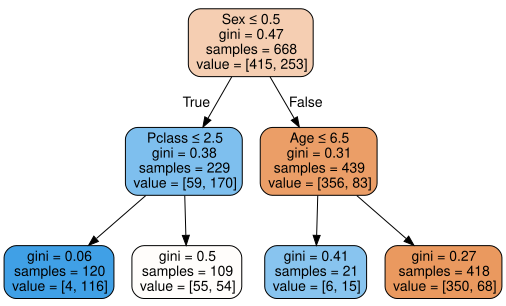

In [29]:
draw_tree(m, train_features, size=10)

Trong mô hình decision tree của sklearn, thuật toán Gini impurity được sử dụng thay vì STD, về cơ bản chúng vẫn cùng 1 chức năng và cách sử dụng.

Quan sát cây, có thể thấy các ô màu vàng sẽ có tỉ lệ sống sot thấp hơn, mỗi ô cũng đã có thông tin ngưỡng, độ thuần và số lượng mẫu.

In [30]:
mean_absolute_error(valid_target, m.predict(valid_features)) # thử train lại model bằng decision tree của sklearn

0.2242152466367713

Có thể thấy độ chính xác giảm nhỏ hơn 1 chút, tuy nhiên đó là vì data set của chúng ta khá ít và cây còn nhỏ. Thử train lại với cây lớn hơn.

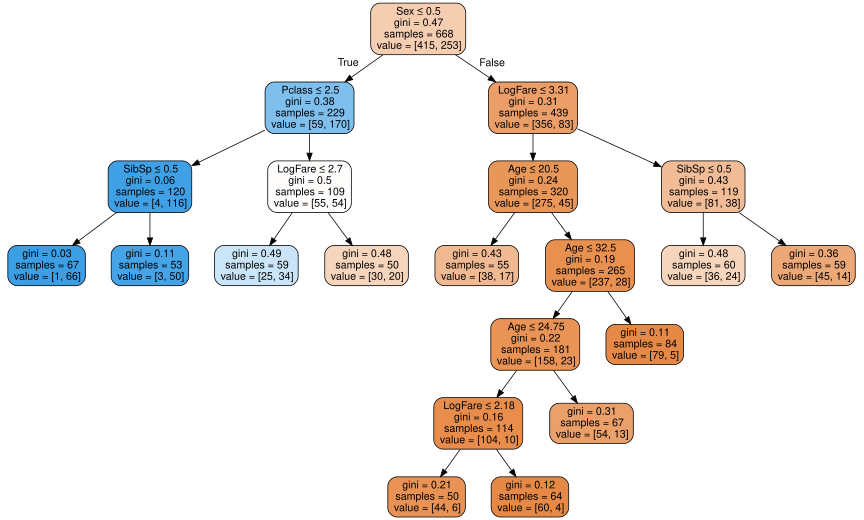

In [31]:
m = DecisionTreeClassifier(min_samples_leaf=50)
m.fit(train_features, train_target)
draw_tree(m, train_features, size=12)

In [32]:
mean_absolute_error(valid_target, m.predict(valid_features))

0.18385650224215247

Có thể thấy kết quả cải thiện rõ rệt.

Tóm lại, Decision Tree được xây dựng từ rất nhiều câu hỏi "Đúng/sai" (1 split), mỗi câu hỏi được chọn bằng cách thử mọi cột/ngưỡng và giữ lại cách chia làm hai nhóm con "thuần" nhất (std hoặc Gini thấp nhất).

# 5. The random forest

Nếu chúng ta cho cây phát triển to hơn, nhiều leaf node hơn, thì sẽ đến lúc các node có rất ít mẫu -> dữ liệu không đủ để cho ra kết quả đáng tin cậy -> dễ overfit. Ngoài ra, 1 cây rất nhạy cảm với dữ liệu, chỉ cần có thay đổi nhỏ trong dữ liệu, cấu trúc cây hoàn toàn thay đổi và cho ra kết quả khác -> 1 cây rất không ổn định.

 Điều này đã dẫn đến ý tưởng "thay vì dùng 1 cây to, ta dùng nhiều cây nhỏ, và tính trung bình kết quả của các cây" của Breiman.

## 5.1. Bagging

Để tạo ra được nhiều cây khác nhau từ một bộ dữ liệu, chúng ta sẽ thực hiện:
* Lấy ngẫu nhiên các hàng ra có hoàn lại", tức một hàng có thể được chọn 2 lần, hàng khác có thể không được chọn lần nào, giống như rút bi từ túi rồi bỏ lại vào túi trước khi rút tiếp. Mỗi lần rút ra một "phiên bản dữ liệu" hơi khác nhau.
* Với mỗi phiên bản dữ liệu khác nhau, tạo 1 cây tương ứng.
* Lặp lại hàng trăm lần -> Hàng trăm cây khác nhau.
* Để dự đoán, cho tất cả các cây cùng thực hiện dự đoán sau đó tính trung bình rồi chốt kết quả cuối.

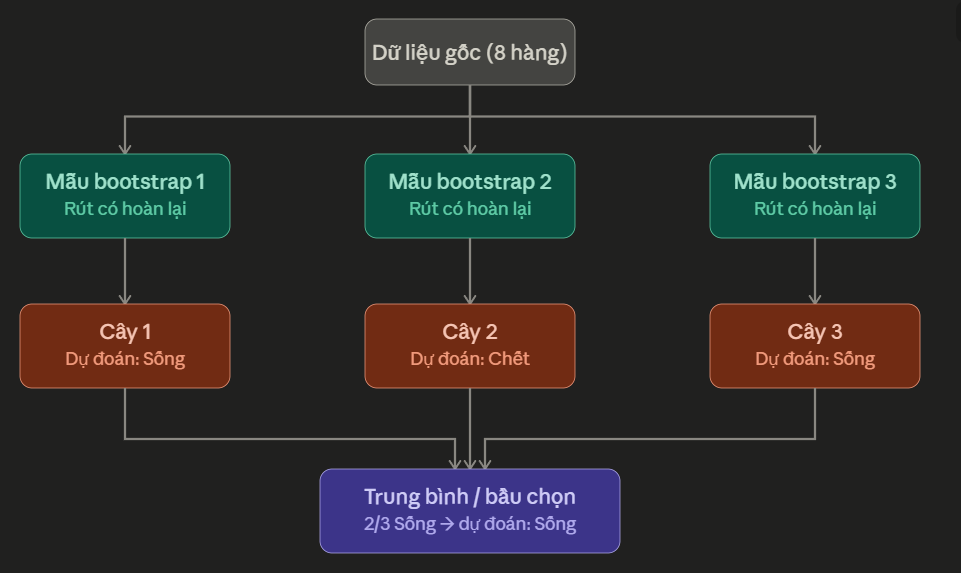

In [ ]:
# hàm tạo một decision tree bằng cách lấy ngẫu nhiên một phần (prop) của dữ liệu train
def get_tree(prop=0.75): 
    # lấy số lượng mẫu trong tập train
    n = len(train_target) 
    # chọn ngẫu nhiên một số lượng mẫu từ tập train dựa trên tỷ lệ prop
    idxs = random.choice(n, int(n*prop)) 
    # tạo một decision tree mới bằng cách sử dụng các mẫu được chọn ngẫu nhiên từ tập train (train_features và train_target) 
    # với min_samples_leaf=5 để tránh overfitting
    return DecisionTreeClassifier(min_samples_leaf=5).fit(train_features.iloc[idxs], train_target.iloc[idxs]) 

In [ ]:
trees = [get_tree() for t in range(100)] # tạo ra 100 cây

In [ ]:
# dự đoán xác suất sống sót cho tập validation bằng cách sử dụng tất cả các cây trong danh sách trees
all_probs = [t.predict(valid_features) for t in trees] 
# tính trung bình xác suất sống sót từ tất cả các cây
avg_probs = np.stack(all_probs).mean(0)

# tính độ chính xác mô hình bằng MAE, MAE càng thấp thì mô hình càng chính xác
mean_absolute_error(valid_target, avg_probs)

0.2268609865470852

Tại sao việc tạo nhiều cây khác nhau và tính trung bình kết quả lại xử lý được vấn đề không ổn định? Điều này xuất phát từ việc mỗi cây sẽ mắc những lỗi khác nhau, ngẫu nhiên và không liên quan tới nhau, khi tổng hợp hàng trăm cây lại thì các lỗi sẽ triệt tiêu nhau (bởi cây này mắc lỗi A nhưng cây khác lại không mắc lỗi đó).

sklearn cũng cung cấp công cụ RandomForest để chúng ta implement:

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(100, min_samples_leaf=5, oob_score=True)
rf.fit(train_features, train_target);
mean_absolute_error(valid_target, rf.predict(valid_features))

0.17937219730941703

sklearn cũng cho ra tỉ lệ chính xác cao hơn. Bởi vì RandomForest của sklearn không chỉ chọn ngãu nhiên các Hàng dữ liệu, mà nó còn chọn ngẫu nhiên các CỘT dữ liệu, thay vì xét tất cả các cột.

Tại sao lại giới hạn thêm như vậy? Vì nếu có một cột cực mạnh (ví dụ "Giới tính" luôn là split tốt nhất), thì hầu như mọi cây trong rừng sẽ chọn đúng cột đó làm split đầu tiên -> các cây trở nên giống nhau, tương quan (correlated) → vậy nhiều cây không còn khắc phục được tính bất ổn định, làm giảm hiệu quả của việc lấy trung bình. Bằng cách ép mỗi split chỉ được nhìn thấy một phần ngẫu nhiên các cột, các cây bị buộc phải khác nhau nhiều hơn, giảm tương quan giữa chúng, và việc lấy trung bình hiệu quả hơn.

## 5.2. Understand RandomForest result
RandomForest còn cung cấp những công cụ để chúng ta dễ dàng quan sát kết quả huấn luyện.
### 5.2.1. OOBError (Out of bag)
Như đã nói trên, mỗi cây trong rừng được train trên một mẫu bootstrap rút ngẫu nhiên có hoàn lại từ dữ liệu gốc. \

Câu hỏi: khi rút có hoàn lại n lần từ n hàng, có bao nhiêu hàng không bao giờ được rút trúng? Về mặt toán học, xác suất một hàng cụ thể không được chọn qua n lần rút tiến gần tới 1/e ≈ 36.8% khi n đủ lớn. Nghĩa là: mỗi cây "chưa từng nhìn thấy" khoảng 1/3 số hàng gốc.

Đây chính là điểm mấu chốt: những hàng mà cây chưa từng thấy trong lúc train chính là một tập validation miễn phí cho riêng cây đó.

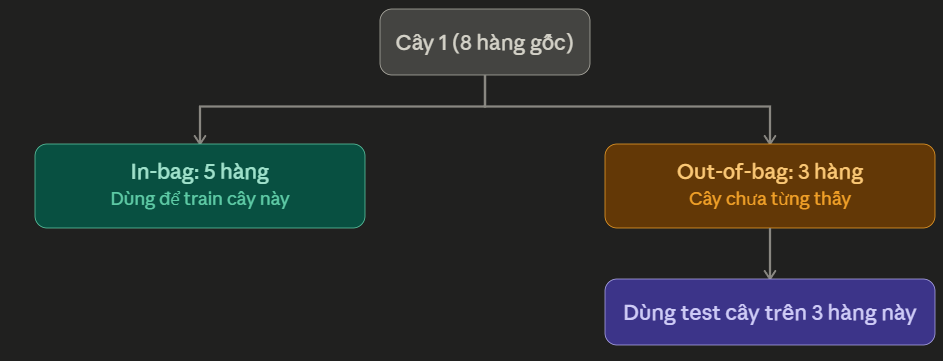

OOB Score là điểm số dự đoán trên tập dữ liệu mà RF không nhìn thấy.

Cách tính OOB error cho cả rừng: Với mỗi hàng dữ liệu gốc, tìm tất cả các cây mà hàng đó là "out-of-bag" (khoảng 1/3 số cây), lấy trung bình dự đoán của chỉ những cây đó cho hàng này, rồi so với giá trị thật. Làm vậy cho tất cả các hàng -> ra một con số lỗi (OOB error) mà không cần tách riêng một tập validation/test! 

=> Random Forest có sẵn cơ chế tự đánh giá, cực kỳ tiện khi dữ liệu ít.

In [ ]:
# Score càng cao -> Mô hình càng chính xác 
print(f"OOB Score (accuracy): {rf.oob_score_:.4f}") 
# Error càng thấp -> Mô hình càng chính xác
print(f"OOB Error: {1 - rf.oob_score_:.4f}")

OOB Score (accuracy): 0.8219
OOB Error: 0.1781


### 5.2.2. Feature importance
Mỗi lần split, thuật toán chọn cột giúp giảm impurity (độ lộn xộn trong nhóm) nhiều nhất. Từ đó suy ra một cách đo tự nhiên: Với mỗi cột, cộng dồn mức giảm impurity mà cột đó tạo ra ở mọi lần nó được dùng để split, trên toàn bộ mọi cây trong rừng. Cột nào cộng dồn được số điểm cao nhất -> cột đó có ảnh hưởng nhất nhất. 

Ví dụ: Trong 8 hành khách, "Giới tính" tạo ra mức giảm gini 0.22 ngay từ split đầu tiên của hầu hết các cây (vì nó là split tốt nhất). Nếu tính tổng trên cả rừng, "Giới tính" sẽ có điểm feature importance cao hơn hẳn "Tuổi".

Hoặc 1 cách đo khác:
* Đo độ chính xác của rừng trên dữ liệu gốc.
* Lấy một cột, xáo trộn (shuffle) ngẫu nhiên giá trị của cột đó giữa các hàng (phá vỡ mối liên hệ giữa cột này và kết quả), giữ nguyên các cột khác.
* Đo lại độ chính xác trên dữ liệu đã bị xáo trộn cột đó.
* Nếu độ chính xác giảm mạnh -> cột đó quan trọng thật sự. Nếu gần như không đổi -> cột đó không đóng góp nhiều.

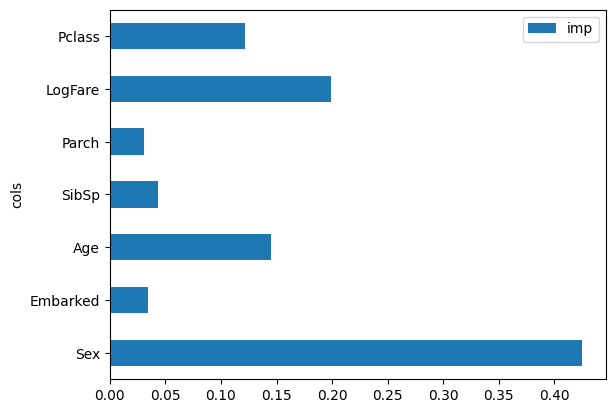

In [42]:
pd.DataFrame(dict(cols=train_features.columns, imp=rf.feature_importances_)).plot('cols', 'imp', 'barh');

### 5.2.3. Estimators
Liệu càng nhiều cây thì mô hình có dự đoán càng chính xác hơn hay không? Thực tế, đến một mức độ nhất định, việc thêm cây vào chỉ khiến tốn công tính toán thêm mà không cải thiện gì, tuy nhiên nó lại không bao giờ làm mô hình tệ đi. Giống như thêm 1 bầu chọn của 1 người vào đám đông thì cũng không làm thay đổi ý kiến đám đông đó.

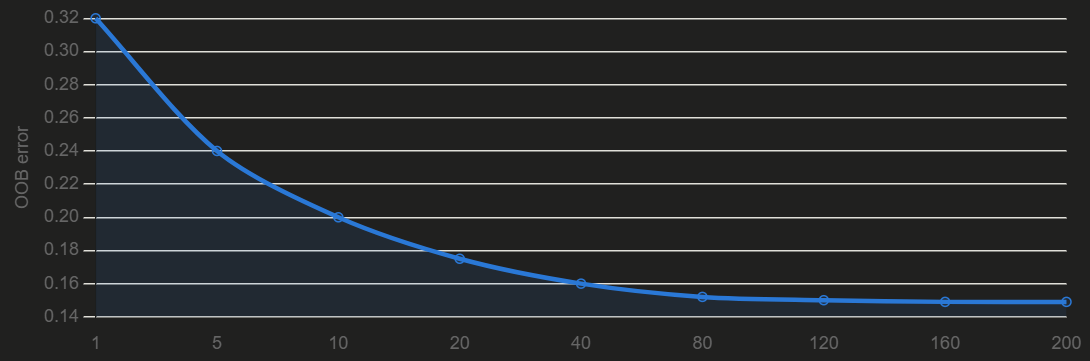

## 5.3. Extrapolation - The problem of RF
RF có một điểm yếu lớn đó chính là khả năng ngoại suy - extrapolation. Có nghĩa là RF dự đoán rất tốt nếu dữ liệu đưa vào nằm trong phạm vi nó đã học, nhưng nếu nằm ngoài thì không.

Bởi vì bản chất một cây sẽ chọn ra 1 giá trị làm ngưỡng, chứ không sử dụng công thức như linear model -> mỗi lá chỉ lưu sẵn trung bình cộng của các giá trị target đã thấy, không phải một phép tính. Nên khi input vượt ra ngoài khoảng đã train, cây vẫn đi theo đúng nhánh (vì luôn lớn hơn mọi ngưỡng), rơi vào đúng cái lá biên cuối cùng, và trả về **y hệt** giá trị trung bình cũ đó - dù input có lớn hơn bao nhiêu đi nữa. Random Forest lấy trung bình nhiều cây cũng không cứu được, vì mọi cây đều mắc chung lỗi này (không phải sai số ngẫu nhiên nên không triệt tiêu nhau khi average).

-> RF chỉ giỏi nội suy (interpolate) trong phạm vi đã học, không ngoại suy (extrapolate) ra ngoài được như linear model.

Vậy nên RF thường được dùng cho các bài toán như:
* Phân loại, hồi quy dựa trên dữ liệu bảng (tabular data): chuẩn đoán bệnh, phát hiện gian lận, dự đoán tỉ lệ sống sót,...
* Quan hệ input-output phi tuyến tính, có tương tác giữa feature -> linear regression khó bắt được

RF không phù hợp cho các bài toán như:
* Time-series: Dữ liệu dự báo, vượt ngoài phạm vi train.
...